In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("/Users/saraseid/Desktop/weather_daily_2022.csv", low_memory=False)

In [3]:
df.head()

,date,TMAX,TMIN,tmax_c,tmin_c,avg_temp_c
0,2022-01-01,13.3,10.0,1.33,1.00,1.165
1,2022-01-02,15.0,2.8,1.50,0.28,0.890
2,2022-01-03,2.8,-5.5,0.28,-0.55,-0.135
3,2022-01-04,1.1,-7.1,0.11,-0.71,-0.300
4,2022-01-05,8.3,-0.5,0.83,-0.05,0.390


In [4]:
df["date"] = pd.to_datetime(df["date"])

<Axes: title={'center': 'Daily Temperature (TMAX and TMIN) in 2022'}, xlabel='date'>

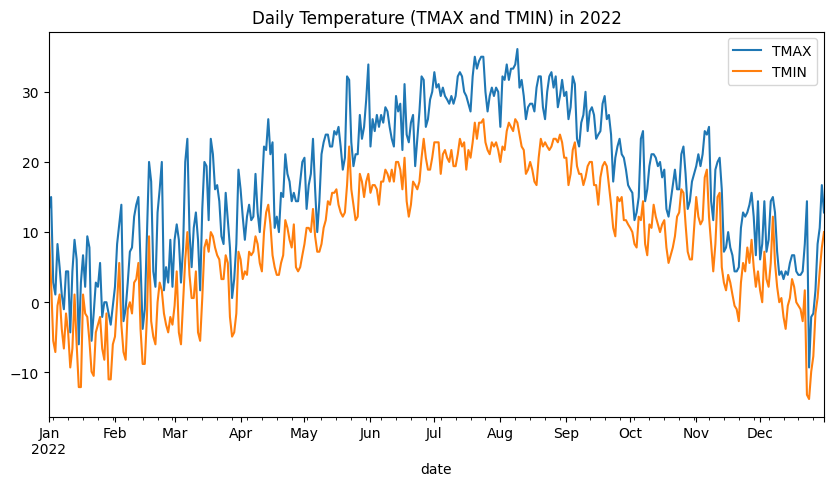

In [5]:
df.plot(
    x="date",
    y=["TMAX", "TMIN"],
    figsize=(10, 5),
    title="Daily Temperature (TMAX and TMIN) in 2022"
)

In [6]:
import zipfile
from pathlib import Path

zip_path = Path("2022-citibike-tripdata")

for z in zip_path.glob("*.zip"):
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall(zip_path)

In [7]:
from pathlib import Path

csv_files = list(Path("2022-citibike-tripdata").glob("*.csv"))
len(csv_files)

36

In [8]:
import pandas as pd

trips = pd.concat(
    (pd.read_csv(f, low_memory=False) for f in csv_files),
    ignore_index=True
)

In [9]:
trips["started_at"] = pd.to_datetime(trips["started_at"])
trips["date"] = trips["started_at"].dt.floor("D")

daily_trips = (
    trips.groupby("date")
    .size()
    .reset_index(name="trip_count")
)

In [10]:
df["date"] = pd.to_datetime(df["date"])

merged_df = pd.merge(
    df,
    daily_trips,
    on="date",
    how="inner"
)

In [12]:
merged_df.head()

,date,TMAX,TMIN,tmax_c,tmin_c,avg_temp_c,trip_count
0,2022-01-01,13.3,10.0,1.33,1.00,1.165,20428
1,2022-01-02,15.0,2.8,1.50,0.28,0.890,43009
2,2022-01-03,2.8,-5.5,0.28,-0.55,-0.135,33189
3,2022-01-04,1.1,-7.1,0.11,-0.71,-0.300,36842
4,2022-01-05,8.3,-0.5,0.83,-0.05,0.390,34230


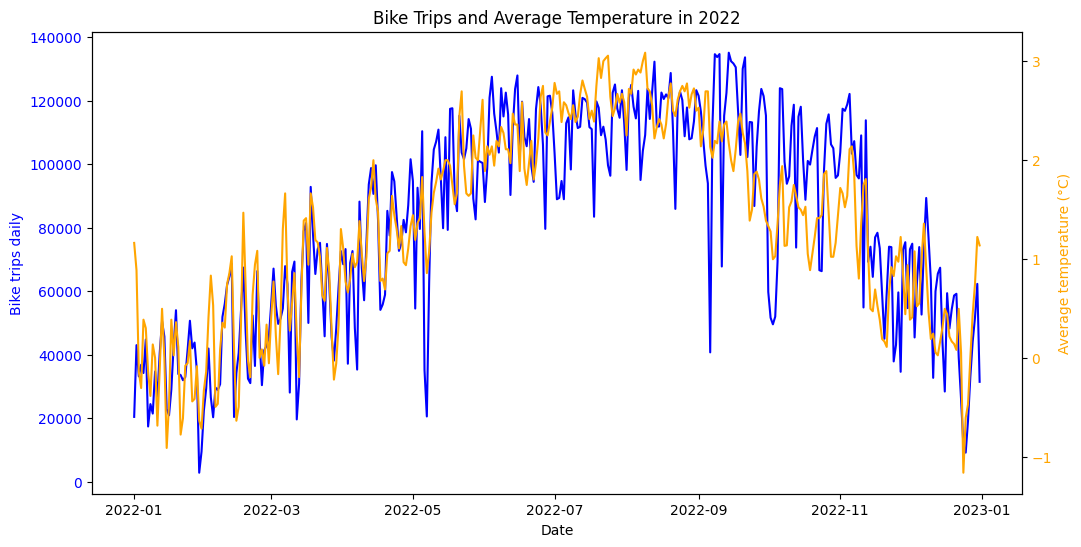

In [14]:
import matplotlib.pyplot as plt
import pandas as pd


merged_df["date"] = pd.to_datetime(merged_df["date"], errors="coerce")
merged_df = merged_df.sort_values("date")

fig, ax1 = plt.subplots(figsize=(12, 6))

)
ax1.plot(
    merged_df["date"],
    merged_df["trip_count"],
    color="blue"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Bike trips daily", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")


ax2 = ax1.twinx()
ax2.plot(
    merged_df["date"],
    merged_df["avg_temp_c"],
    color="orange"
)
ax2.set_ylabel("Average temperature (°C)", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Bike Trips and Average Temperature in 2022")
plt.show()

This visualization was created using Matplotlib’s object-oriented approach. A primary axis was used to plot daily bike trip counts, and a secondary axis was added with twinx() to plot average temperature on a different scale. This approach allows two related variables with different units to be compared over the same time period in a single chart.